Learning rate set to 0.027837
0:	learn: 0.6577491	total: 136ms	remaining: 2m 15s
1:	learn: 0.6520866	total: 140ms	remaining: 1m 9s
2:	learn: 0.6449375	total: 144ms	remaining: 47.9s
3:	learn: 0.6384503	total: 148ms	remaining: 37s
4:	learn: 0.6326496	total: 153ms	remaining: 30.4s
5:	learn: 0.6267749	total: 157ms	remaining: 26.1s
6:	learn: 0.6207875	total: 162ms	remaining: 22.9s
7:	learn: 0.6143503	total: 165ms	remaining: 20.5s
8:	learn: 0.6088493	total: 167ms	remaining: 18.4s
9:	learn: 0.6024413	total: 170ms	remaining: 16.9s
10:	learn: 0.5970889	total: 174ms	remaining: 15.6s
11:	learn: 0.5920145	total: 177ms	remaining: 14.6s
12:	learn: 0.5857385	total: 181ms	remaining: 13.7s
13:	learn: 0.5817706	total: 184ms	remaining: 13s
14:	learn: 0.5746699	total: 188ms	remaining: 12.3s
15:	learn: 0.5692727	total: 192ms	remaining: 11.8s
16:	learn: 0.5641272	total: 195ms	remaining: 11.3s
17:	learn: 0.5598549	total: 199ms	remaining: 10.8s
18:	learn: 0.5557343	total: 202ms	remaining: 10.4s
19:	learn: 0.5

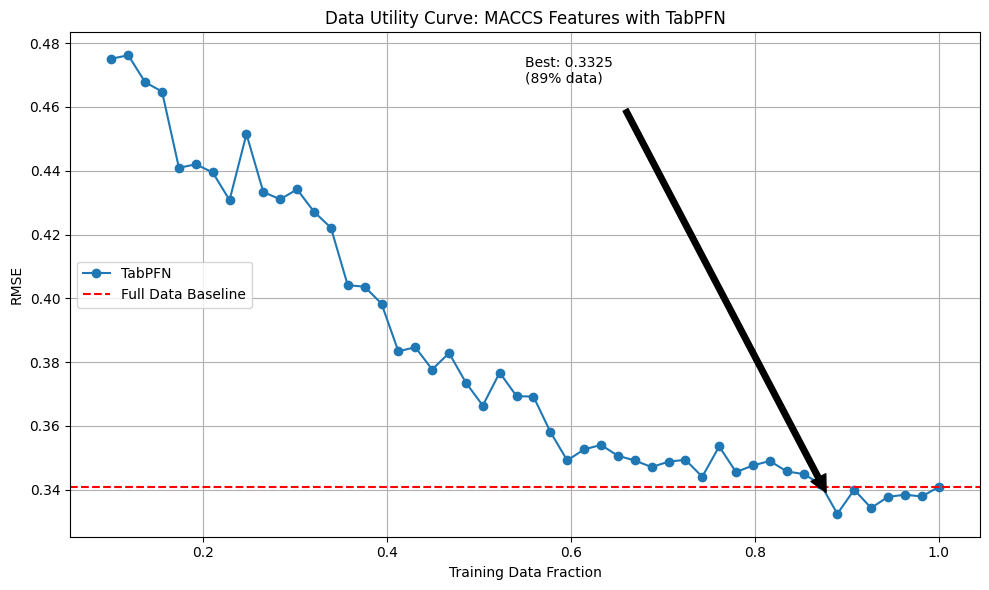

In [1]:
#通过数据效用曲线来评估数据量的影响
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from catboost import CatBoostRegressor

maccs_df = pd.read_excel('categorized_maccs.xlsx', sheet_name='Sheet1', header=0)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']

constant_cols = X.columns[X.nunique() == 1]
X = X.drop(columns=constant_cols)
# 提取分层采样依据列
stratify_column = maccs_df['chemical class-98']

Seed = 50
# 固定测试集（全量数据的20%）
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=Seed,
    shuffle=True  # 重要！确保训练集顺序可复现
)

# 定义数据比例范围（总训练数据的10%-100%）
fractions = np.linspace(0.1, 1.0, 50)
rmse_scores = []

# 预训练模型初始化（避免重复加载）
reg = CatBoostRegressor(random_state=Seed)  # 根据硬件选择cpu/cuda

# 构建效用曲线
for frac in fractions:
    # 计算实际样本数
    n_samples = int(len(X_train_full) * frac)

    # 提取递增数据集（利用预打乱特性）
    X_train = X_train_full.iloc[:n_samples]
    y_train = y_train_full.iloc[:n_samples]

    # 模型训练与推理
    reg.fit(X_train.values, y_train.values)  # 转换为numpy加速
    y_pred = reg.predict(X_test.values)

    # 评估指标
    rmse = np.sqrt(np.mean((y_test.values - y_pred)**2))
    rmse_scores.append(rmse)
    print(f"Data Fraction: {frac:.1f} | Samples: {n_samples} | RMSE: {rmse:.4f}")

# 可视化曲线
plt.figure(figsize=(10, 6))
plt.plot(fractions, rmse_scores, 'o-', label='TabPFN')
plt.axhline(y=rmse_scores[-1], color='r', linestyle='--', label='Full Data Baseline')

# 标注关键拐点
min_idx = np.argmin(rmse_scores)
plt.annotate(f'Best: {rmse_scores[min_idx]:.4f}\n({fractions[min_idx]:.0%} data)',
             xy=(fractions[min_idx], rmse_scores[min_idx]),
             xytext=(0.5, 0.9), textcoords='axes fraction',
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Data Utility Curve: MACCS Features with TabPFN')
plt.xlabel('Training Data Fraction')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
# 导出学习曲线数据至CSV（用于Origin拟合）
curve_df = pd.DataFrame({
    'Data Fraction': fractions,
    'RMSE': rmse_scores,
    'Samples': [int(len(X_train_full)*frac) for frac in fractions]  # 可选：添加样本数列
})
curve_df.to_csv('learning_curve_50.csv', index=False, float_format='%.5f')